# RAG agêntico

Um RAG simples busca uma vez e responde com o que veio, esteja o trecho certo ou não. Quando a pergunta chega em linguagem do dia a dia, a busca traz trechos vizinhos que não respondem. RAG agêntico é colocar decisões em volta da busca: avaliar se os trechos servem, reescrever a pergunta quando não servem, recorrer a outra fonte quando o documento não tem a resposta e escolher a fonte antes de buscar.

Este notebook monta essas decisões como nós e arestas de um grafo, seguindo o tutorial de RAG agêntico da documentação do LangGraph, sobre o Código de Defesa do Consumidor.

In [55]:
# No Google Colab, descomente e rode uma vez.

# !pip install -q langchain langchain-openai langchain-chroma langgraph beautifulsoup4
# !pip install -q langchain-groq langchain-google-genai

# import os
# from google.colab import userdata

# os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
# os.environ["GROQ_API_KEY"] = userdata.get("GROQ_API_KEY")
# os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
# os.environ["OPENROUTER_API_KEY"] = userdata.get("OPENROUTER_API_KEY")

In [56]:
import json
import os
import re
import urllib.request
from pathlib import Path
from typing import Literal
from urllib.parse import quote

import pandas as pd
from bs4 import BeautifulSoup
from IPython.display import Image
from pydantic import BaseModel, Field

from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.embeddings import init_embeddings
from langchain.messages import HumanMessage, SystemMessage, ToolMessage
from langchain.tools import tool
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import END, START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import Command

In [57]:
model = init_chat_model("openai:gpt-4.1-mini", temperature=0.0)
embeddings = init_embeddings("openai:text-embedding-3-small")

# Outros modelos de embedding. Ao trocar, apague a pasta chroma_cdc, porque o tamanho do vetor muda.
# embeddings = init_embeddings("openai:openai/text-embedding-3-small", base_url="https://openrouter.ai/api/v1", api_key=os.environ["OPENROUTER_API_KEY"], check_embedding_ctx_length=False)
# from agentkit import Embeddings
# embeddings = Embeddings("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

## O índice do CDC

O documento é o Código de Defesa do Consumidor, a Lei 8.078/1990, no HTML compilado do Planalto, sem o texto riscado, que foi revogado. O código se cita por artigo, então o corte segue a numeração: um "Art." menor que o anterior é citação de outra lei e fica no artigo que a cita. Cada artigo vira um trecho, e o maior tem pouco mais de 3 mil caracteres.

In [58]:
URL = "https://www.planalto.gov.br/ccivil_03/leis/l8078compilado.htm"
FILE = Path("cdc.htm")

if not FILE.exists():
    request = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(request, timeout=60) as response:
        FILE.write_bytes(response.read())

soup = BeautifulSoup(FILE.read_text(encoding="cp1252"), "html.parser")
for revoked in soup.find_all(["strike", "s"]):
    revoked.decompose()
text = re.sub(r"\s+", " ", soup.get_text(" "))

print(len(text))
print(text[text.index("Art. 49."):][:300])

82804
Art. 49. O consumidor pode desistir do contrato, no prazo de 7 dias a contar de sua assinatura ou do ato de recebimento do produto ou serviço, sempre que a contratação de fornecimento de produtos e serviços ocorrer fora do estabelecimento comercial, especialmente por telefone ou a domicílio. Parágra


In [59]:
def split_articles(text: str) -> list[Document]:
    """Corta o texto no início de cada artigo e guarda o número do artigo no trecho."""
    articles = []
    for part in re.split(r"(?=Art\. \d+)", text)[1:]:
        number = re.match(r"Art\. (\d+(?:-[A-Z])?)", part)[1]
        if articles and int(number.split("-")[0]) < int(articles[-1].metadata["article"].split("-")[0]):
            articles[-1].page_content += part
        else:
            articles.append(Document(part.strip(), metadata={"article": number}))
    return articles


articles = split_articles(text)
print(len(articles), [doc.metadata["article"] for doc in articles[:12]])

130 ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12']


In [60]:
vector_store = Chroma(
    collection_name="cdc",
    embedding_function=embeddings,
    persist_directory="./chroma_cdc",
    collection_metadata={"hnsw:space": "cosine"},
)

if not vector_store.get()["ids"]:
    vector_store.add_documents(documents=articles, ids=[f"art-{doc.metadata['article']}" for doc in articles])

print("trechos indexados:", len(vector_store.get()["ids"]))

trechos indexados: 130


In [61]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})


def format_docs(documents: list) -> str:
    """Junta os trechos em um texto só, com o artigo na frente de cada um."""
    return "\n\n".join(f"[art. {doc.metadata['article']}] {doc.page_content}" for doc in documents)


@tool
def search_cdc(query: str) -> str:
    """Busca trechos do Código de Defesa do Consumidor relacionados à consulta."""
    return format_docs(retriever.invoke(query))

## Onde o RAG simples falha

O RAG simples é o retriever embrulhado em ferramenta, com o `create_agent` em volta. A pergunta abaixo está escrita como um consumidor escreveria; o código não fala em nome sujo, e sim em informações negativas nos cadastros e bancos de dados de consumidores. Antes de rodar, tente prever: o agente acha a resposta?

In [62]:
SYSTEM = """# Papel
Você responde dúvidas de consumidores.

# Regras
Para perguntas sobre direitos do consumidor, use a ferramenta e termine a resposta com o artigo, no formato (art. 49).
Se não encontrar o artigo, diga que não encontrou.
Para o resto, responda direto.
Seja breve: no máximo três frases."""

rag_agent = create_agent(model, tools=[search_cdc], system_prompt=SYSTEM)

In [63]:
QUESTION = "Por quanto tempo meu nome pode ficar sujo?"

result = rag_agent.invoke({"messages": [HumanMessage(QUESTION)]})

print("caminho  :", " -> ".join(message.type for message in result["messages"]))
print("consultas:", [call["args"]["query"] for message in result["messages"] if message.type == "ai" for call in message.tool_calls])
print("resposta :", result["messages"][-1].content)

caminho  : human -> ai -> tool -> ai
consultas: ['tempo nome sujo']
resposta : O Código de Defesa do Consumidor não especifica um prazo exato para o nome ficar sujo, mas geralmente o registro de inadimplência pode permanecer por até 5 anos, desde que a dívida não seja paga ou negociada. Após esse período, a negativação deve ser removida. (art. 73)


In [64]:
print(search_cdc.invoke({"query": QUESTION}))

[art. 73] Art. 73. Deixar de corrigir imediatamente informação sobre consumidor constante de cadastro, banco de dados, fichas ou registros que sabe ou deveria saber ser inexata: Pena Detenção de um a seis meses ou multa.

[art. 18] Art. 18. Os fornecedores de produtos de consumo duráveis ou não duráveis respondem solidariamente pelos vícios de qualidade ou quantidade que os tornem impróprios ou inadequados ao consumo a que se destinam ou lhes diminuam o valor, assim como por aqueles decorrentes da disparidade, com a indicações constantes do recipiente, da embalagem, rotulagem ou mensagem publicitária, respeitadas as variações decorrentes de sua natureza, podendo o consumidor exigir a substituição das partes viciadas. § 1° Não sendo o vício sanado no prazo máximo de trinta dias, pode o consumidor exigir, alternativamente e à sua escolha: I - a substituição do produto por outro da mesma espécie, em perfeitas condições de uso; II - a restituição imediata da quantia paga, monetariamente at

Os três trechos só tangenciam o assunto: o art. 73 pune quem não corrige informação inexata, o art. 18 trata de produto com defeito e o art. 71, de cobrança abusiva. A resposta está no art. 43, § 1º, que limita as informações negativas a cinco anos.

O agente buscou uma vez, não achou o prazo e respondeu que ele não existe. Nada confere se os trechos respondem à pergunta. As próximas seções acrescentam essa decisão e as outras.

## Avaliação dos trechos

O primeiro passo é saber se a busca deu certo. A distância de cosseno não serve, porque não existe um limiar que valha para toda pergunta. A alternativa é pedir ao modelo que julgue: ele recebe a pergunta e os trechos e responde sim ou não, em saída estruturada.

In [65]:
GRADE_PROMPT = """# Papel
Você avalia se trechos recuperados de um documento respondem a uma pergunta.

# Regras
Responda 'sim' só se algum trecho traz a informação que a pergunta pede, mesmo com outras palavras.
Responda 'nao' se os trechos só compartilham palavras ou o tema geral com a pergunta.

# Pergunta
<pergunta>
{question}
</pergunta>

# Trechos
<trechos>
{context}
</trechos>"""


class GradeDocuments(BaseModel):
    """Veredito binário sobre a relevância dos trechos."""

    binary_score: Literal["sim", "nao"] = Field(description="'sim' se os trechos respondem à pergunta, 'nao' se não")


grader = model.with_structured_output(GradeDocuments)

In [66]:
for query in [QUESTION, "Prazo máximo de manutenção de informações negativas do consumidor em cadastros"]:
    context = search_cdc.invoke({"query": query})
    verdict = grader.invoke(GRADE_PROMPT.format(context=context, question=QUESTION))
    print(f"{verdict.binary_score:3s} | busca por {query!r}")

nao | busca por 'Por quanto tempo meu nome pode ficar sujo?'
sim | busca por 'Prazo máximo de manutenção de informações negativas do consumidor em cadastros'


Os dois vereditos julgam a mesma pergunta do consumidor; muda só a busca. Os trechos da pergunta coloquial foram reprovados, e os da versão no vocabulário do código, aprovados. O avaliador não melhora a busca, só diz se ela funcionou, e é esse sinal que vai decidir o próximo passo do grafo.

### Exercício 1

O avaliador devolve só sim ou não. Crie uma versão do `GradeDocuments` com um campo `reason`, uma frase que justifique o veredito, e um avaliador com ela. Rode as duas buscas acima com o avaliador novo: o que ele apontou nos trechos reprovados?

In [67]:
# Seu código aqui

## Reescrita da pergunta

Quando os trechos são reprovados, dá para tentar de novo com outra consulta. O modelo conhece o vocabulário do consumidor e o da lei, então pode reescrever a pergunta nos termos do documento.

In [68]:
REWRITE_PROMPT = """# Papel
Você reescreve perguntas para a busca no Código de Defesa do Consumidor.

# Regras
Reescreva a pergunta com os termos formais que o código usaria para o assunto.
Responda só com a pergunta reescrita.

# Pergunta
<pergunta>
{question}
</pergunta>"""

rewritten = model.invoke(REWRITE_PROMPT.format(question=QUESTION)).content

print(rewritten)
print([doc.metadata["article"] for doc in retriever.invoke(rewritten)])

Qual é o prazo máximo para a manutenção do registro de restrição de crédito no nome do consumidor?
['73', '43', '104-A']


Compare os artigos com as da busca original. A reescrita nem sempre acerta de primeira, porque aposta em um vocabulário, e só a avaliação diz se a aposta deu certo. Por isso, no grafo, reescrita e avaliação formam um ciclo.

### Exercício 2

Escreva quatro perguntas com expressões do dia a dia, como "me arrependi da compra" ou "veio quebrado". Reescreva cada uma com o `REWRITE_PROMPT` e compare os artigos que o `retriever` traz para a pergunta e para a reescrita. Em quais a reescrita trouxe outros artigos, e que termos da lei o modelo usou no lugar das suas expressões?

In [69]:
# Seu código aqui

### O grafo

O `generate_query_or_respond` chama o modelo com a ferramenta ligada, e ele decide se busca ou responde. O `retrieve` executa a busca. A aresta que sai dele, `grade_documents`, chama o avaliador e escolhe entre `generate_answer` e `rewrite_question`. A pergunta reescrita volta para o começo.

O estado ganha uma chave, `rewrites`, que conta as reescritas e garante o fim do ciclo quando a resposta não está no documento.

In [70]:
class RAGState(MessagesState):
    rewrites: int

In [71]:
MAX_REWRITES = 2

RAG_SYSTEM = """# Papel
Você responde dúvidas de consumidores consultando o Código de Defesa do Consumidor com a ferramenta de busca.

# Regras
Toda pergunta que peça informação passa pela busca, mesmo que você ache que sabe a resposta ou que o código não trate do assunto.
Só responda sem buscar a cumprimentos e conversa.
Se a última mensagem do usuário for uma pergunta reescrita, busque de novo com ela."""

model_with_tools = model.bind_tools([search_cdc])


def generate_query_or_respond(state: RAGState) -> dict:
    """Chama o modelo com a ferramenta de busca ligada; ele decide se busca ou responde."""
    return {"messages": [model_with_tools.invoke([SystemMessage(RAG_SYSTEM)] + state["messages"])]}


def grade_documents(state: RAGState) -> Literal["generate_answer", "rewrite_question"]:
    """Avalia os trechos da última busca contra a pergunta original."""
    question, context = state["messages"][0].content, state["messages"][-1].content
    verdict = grader.invoke(GRADE_PROMPT.format(context=context, question=question))
    if verdict.binary_score == "sim" or state.get("rewrites", 0) >= MAX_REWRITES:
        return "generate_answer"
    return "rewrite_question"

In [72]:
GENERATE_PROMPT = """# Papel
Você responde perguntas sobre direitos do consumidor a partir de trechos de documentos.

# Regras
Responda usando apenas os trechos do contexto.
Cite a fonte entre parênteses, como ela aparece no contexto.
Seja breve: no máximo três frases.
Se o contexto não bastar, diga que não encontrou e não cite fonte.

# Contexto
<contexto>
{context}
</contexto>

# Pergunta
<pergunta>
{question}
</pergunta>"""


def rewrite_question(state: RAGState) -> dict:
    """Reescreve a pergunta original nos termos do código."""
    rewritten = model.invoke(REWRITE_PROMPT.format(question=state["messages"][0].content)).content
    return {"messages": [HumanMessage(rewritten)], "rewrites": state.get("rewrites", 0) + 1}


def generate_answer(state: RAGState) -> dict:
    """Gera a resposta com a pergunta original e os trechos da última busca."""
    question, context = state["messages"][0].content, state["messages"][-1].content
    return {"messages": [model.invoke(GENERATE_PROMPT.format(context=context, question=question))]}

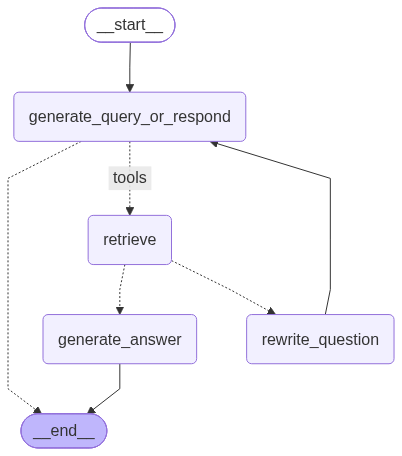

In [73]:
rag_builder = StateGraph(RAGState)

# nós
rag_builder.add_node("generate_query_or_respond", generate_query_or_respond)
rag_builder.add_node("retrieve", ToolNode([search_cdc]))
rag_builder.add_node("rewrite_question", rewrite_question)
rag_builder.add_node("generate_answer", generate_answer)

# arestas
rag_builder.add_edge(START, "generate_query_or_respond")
rag_builder.add_conditional_edges("generate_query_or_respond", tools_condition, {"tools": "retrieve", END: END})
rag_builder.add_conditional_edges("retrieve", grade_documents)
rag_builder.add_edge("rewrite_question", "generate_query_or_respond")
rag_builder.add_edge("generate_answer", END)

rag_graph = rag_builder.compile()
Image(rag_graph.get_graph().draw_mermaid_png())

O `grade_documents` é uma aresta, e não um nó: escolhe o destino e não escreve no estado, por isso não aparece como caixa no desenho. A função `show` roda o grafo, imprime cada nó que executa e, no fim, a resposta.

In [74]:
def show(graph, question: str) -> None:
    """Roda o grafo, imprime cada nó executado e, no fim, a resposta."""
    for step in graph.stream({"messages": [HumanMessage(question)]}, stream_mode="updates"):
        for node, update in step.items():
            print(node)
    print()
    print(update["messages"][-1].content)

In [75]:
show(rag_graph, QUESTION)

generate_query_or_respond
retrieve
rewrite_question
generate_query_or_respond
retrieve
rewrite_question
generate_query_or_respond
retrieve
generate_answer

Não encontrei informações sobre o tempo que o nome pode ficar sujo no contexto fornecido.


A primeira busca trouxe os mesmos trechos de antes, a avaliação os reprovou e o grafo passou pelo `rewrite_question`. A segunda busca, com a pergunta reescrita, trouxe o art. 43. A resposta é gerada para a pergunta original, e não para a reescrita, que existe só para a busca.

A próxima pergunta é sobre defesa do consumidor, mas a fundação do Idec não está no código. Antes de rodar, tente prever quantas buscas o grafo faz.

In [76]:
show(rag_graph, "Em que ano foi fundado o Idec?")

generate_query_or_respond
retrieve
rewrite_question
generate_query_or_respond
retrieve
rewrite_question
generate_query_or_respond
retrieve
generate_answer

Não encontrei essa informação no contexto fornecido.


Foram três buscas, a original e uma por reescrita, até o `rewrites` chegar ao `MAX_REWRITES` e o grafo responder com o que tinha. Reescrever não resolve o que o documento não tem.

## Correção com outra fonte

Quando o documento não tem a resposta, o RAG corretivo troca de fonte: se a avaliação reprovar mesmo depois das reescritas, o grafo busca na web. A fonte aqui é a Wikipédia em português, pela API pública, que não exige chave.

In [77]:
def fetch(url: str) -> dict:
    """Faz um GET e devolve o JSON da resposta."""
    request = urllib.request.Request(url, headers={"User-Agent": "ia-agentica-aula/1.0"})
    with urllib.request.urlopen(request, timeout=30) as response:
        return json.load(response)


@tool
def search_wikipedia(query: str) -> str:
    """Busca na Wikipédia em português e devolve a introdução dos dois artigos mais relevantes."""
    pages = fetch(
        "https://pt.wikipedia.org/w/api.php?action=query&format=json&generator=search"
        f"&gsrsearch={quote(query)}&gsrlimit=2&prop=extracts&exintro=1&explaintext=1"
    )["query"]["pages"]
    return "\n\n".join(f"[Wikipédia: {page['title']}] {page['extract']}" for page in pages.values())

In [78]:
print(search_wikipedia.invoke({"query": "Em que ano foi fundado o Idec?"}))

[Wikipédia: Controvérsia sobre alimentos geneticamente modificados] Consumidores, agricultores, empresas de biotecnologia, órgãos reguladores governamentais, organizações não governamentais e cientistas têm estado envolvidos em controvérsias a respeito de alimentos e outros produtos derivados de culturas agrícolas geneticamente modificadas em vez de culturas convencionais, bem como sobre outros usos da engenharia genética na produção de alimentos. As principais áreas de controvérsia relacionadas aos alimentos geneticamente modificados (alimentos transgênicos ou OGMs) incluem: se esses alimentos deveriam ser rotulados; o papel dos órgãos reguladores governamentais; a objetividade da pesquisa e das publicações científicas; o efeito das culturas geneticamente modificadas sobre a saúde e o meio ambiente; o impacto sobre a resistência a pesticidas; o impacto dessas culturas para os agricultores; e o papel delas na alimentação da população mundial. Além disso, produtos derivados de organismo

O primeiro artigo só compartilha palavras com a pergunta; o do Idec vem em segundo. A ferramenta devolve texto no mesmo formato do `search_cdc`, com a fonte entre colchetes, e por isso o mesmo `generate_answer` serve para as duas. O nó `web_search` busca a pergunta original e acrescenta o resultado ao histórico como uma `ToolMessage`; o `generate_answer` lê a última mensagem, como antes.

In [79]:
def web_search(state: RAGState) -> dict:
    """Busca a pergunta original na Wikipédia."""
    result = search_wikipedia.invoke({"query": state["messages"][0].content})
    return {"messages": [ToolMessage(result, tool_call_id="web_search")]}


def grade_or_search(state: RAGState) -> Literal["generate_answer", "rewrite_question", "web_search"]:
    """Como o grade_documents, mas recorre à Wikipédia quando as reescritas acabam."""
    question, context = state["messages"][0].content, state["messages"][-1].content
    if grader.invoke(GRADE_PROMPT.format(context=context, question=question)).binary_score == "sim":
        return "generate_answer"
    return "web_search" if state.get("rewrites", 0) >= MAX_REWRITES else "rewrite_question"

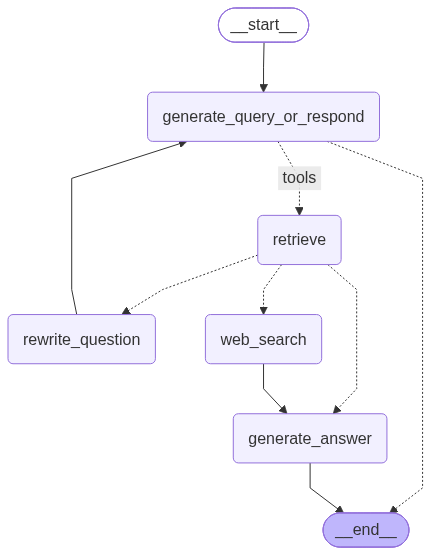

In [80]:
corrective_builder = StateGraph(RAGState)

# nós
corrective_builder.add_node("generate_query_or_respond", generate_query_or_respond)
corrective_builder.add_node("retrieve", ToolNode([search_cdc]))
corrective_builder.add_node("rewrite_question", rewrite_question)
corrective_builder.add_node("web_search", web_search)
corrective_builder.add_node("generate_answer", generate_answer)

# arestas
corrective_builder.add_edge(START, "generate_query_or_respond")
corrective_builder.add_conditional_edges("generate_query_or_respond", tools_condition, {"tools": "retrieve", END: END})
corrective_builder.add_conditional_edges("retrieve", grade_or_search)
corrective_builder.add_edge("rewrite_question", "generate_query_or_respond")
corrective_builder.add_edge("web_search", "generate_answer")
corrective_builder.add_edge("generate_answer", END)

corrective_graph = corrective_builder.compile()
Image(corrective_graph.get_graph().draw_mermaid_png())

In [81]:
show(corrective_graph, "Em que ano foi fundado o Idec?")

generate_query_or_respond
retrieve
rewrite_question
generate_query_or_respond
retrieve
rewrite_question
generate_query_or_respond
retrieve
web_search
generate_answer

O Idec foi fundado em 1987 (Wikipédia: Instituto de Defesa de Consumidores).


O caminho repete o do grafo anterior até a última avaliação, e ali o grafo foi à Wikipédia; a resposta cita o artigo de onde saiu o ano. O código vem antes porque é a fonte de autoridade para os direitos do consumidor, e a web entra só como correção.

### Exercício 3

O `web_search` busca com a pergunta original, e a busca da Wikipédia funciona melhor com palavras-chave do que com perguntas inteiras. Escreva uma função `keywords`, que chama o modelo com um prompt seu e devolve de duas a quatro palavras-chave para a pergunta. Compare os títulos dos artigos que o `search_wikipedia` traz para a pergunta inteira e para as palavras-chave, com a pergunta da fundação do Idec e com uma pergunta sua fora do CDC.

In [82]:
# Seu código aqui

## Roteamento

O grafo corretivo só chega à Wikipédia depois de três buscas, três avaliações e duas reescritas, mesmo quando a pergunta deixa claro que o código não tem a resposta. O roteamento decide na entrada: um nó classifica a pergunta e manda para o CDC, para a Wikipédia ou, se for conversa, para uma resposta direta.

In [83]:
ROUTE_PROMPT = """# Papel
Você é o roteador de um assistente que responde dúvidas de consumidores.

# Regras
Classifique a pergunta do usuário em exatamente uma de três fontes: cdc, web ou conversa.
CDC cobre direitos, deveres, prazos e práticas proibidas nas relações de consumo.
Web cobre fatos gerais, como órgãos, empresas, história, datas e números, mesmo que sejam sobre defesa do consumidor.
Conversa cobre cumprimentos e mensagens que não pedem informação."""


class RouteQuery(BaseModel):
    """Fonte escolhida para responder à pergunta."""

    source: Literal["cdc", "web", "conversa"]


router = model.with_structured_output(RouteQuery)

ROUTES = {"cdc": "generate_query_or_respond", "web": "web_search", "conversa": "respond"}


def route_question(state: RAGState) -> Command[Literal["generate_query_or_respond", "web_search", "respond"]]:
    """Classifica a pergunta e segue direto para o nó da fonte escolhida."""
    route = router.invoke([SystemMessage(ROUTE_PROMPT)] + state["messages"])
    return Command(goto=ROUTES[route.source])


def respond(state: RAGState) -> dict:
    """Responde à conversa sem ferramenta."""
    return {"messages": [model.invoke(state["messages"])]}

O `route_question` usa `Command`: o nó escolhe o destino no `goto`, e a anotação `Command[Literal[...]]` diz ao grafo quais nós podem vir depois dele. O resto é o grafo corretivo.

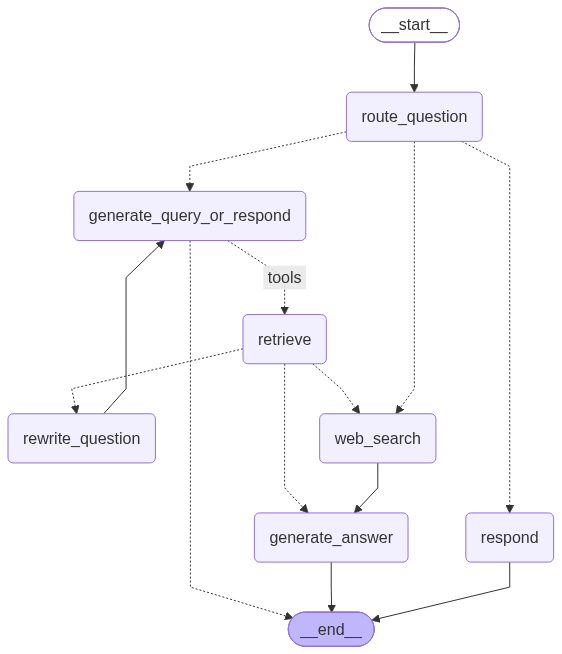

In [84]:
routed_builder = StateGraph(RAGState)

# nós
routed_builder.add_node("route_question", route_question)
routed_builder.add_node("respond", respond)
routed_builder.add_node("generate_query_or_respond", generate_query_or_respond)
routed_builder.add_node("retrieve", ToolNode([search_cdc]))
routed_builder.add_node("rewrite_question", rewrite_question)
routed_builder.add_node("web_search", web_search)
routed_builder.add_node("generate_answer", generate_answer)

# arestas
routed_builder.add_edge(START, "route_question")
routed_builder.add_edge("respond", END)
routed_builder.add_conditional_edges("generate_query_or_respond", tools_condition, {"tools": "retrieve", END: END})
routed_builder.add_conditional_edges("retrieve", grade_or_search)
routed_builder.add_edge("rewrite_question", "generate_query_or_respond")
routed_builder.add_edge("web_search", "generate_answer")
routed_builder.add_edge("generate_answer", END)

routed_graph = routed_builder.compile()
Image(routed_graph.get_graph().draw_mermaid_png())

In [85]:
show(routed_graph, "Em que ano foi fundado o Idec?")

route_question
web_search
generate_answer

O Idec foi fundado em 1987 (Wikipédia: Instituto de Defesa de Consumidores).


In [86]:
show(routed_graph, "Bom dia, tudo bem?")

route_question
respond

Bom dia! Tudo bem, e com você? Como posso ajudar hoje?


A pergunta sobre a fundação do Idec foi direto para a Wikipédia, sem passar pelo código, e a saudação foi respondida sem busca. O custo é uma chamada a mais em toda pergunta, a do roteador. E um roteador que erra manda uma pergunta sobre direitos para a web, onde nenhuma avaliação a traz de volta.

### Exercício 4

O roteador manda toda pergunta para uma das três fontes, mesmo quando ela não tem nada a ver com consumo. Crie um roteador com uma quarta fonte, `fora_de_escopo`, para perguntas como receitas ou futebol, acrescentando o valor a uma cópia do `RouteQuery` e uma regra para ele a uma cópia do `ROUTE_PROMPT`. Passe algumas perguntas pelo roteador antigo e pelo novo. Para onde o antigo mandava as perguntas fora de escopo?

In [87]:
# Seu código aqui